# NB05 — Does the KC Tree Encode Real Prerequisites?

**RQ:** RQ1.3 — "How do we exploit the KC prerequisite tree so a low prior on a parent
KC suppresses its children?" This presumes the authored tree encodes genuine
prerequisite structure. We test that assumption directly: does a student's parent-KC
accuracy actually predict child-KC accuracy above baseline, and does a purely
data-driven accuracy-ordering agree with the authored parent->child edges?


In [1]:
import os, sys
sys.path.insert(0, "/root/src" if os.path.exists("/root/src") else "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from itertools import combinations

from noxed import data, prerequisites, tracking, paths

DATA_DIR = paths.data_dir(); OUT = paths.outcomes_dir(); FIG = paths.figures_dir()


## 1. Derive authored parent->child edges from the KC tree

In [2]:
tree = data.parse_kc_tree(DATA_DIR / "tree_translation.txt")
kc_meta = data.load_kc_metadata(DATA_DIR)
kc_tax = data.attach_kc_taxonomy(kc_meta, tree)

edges = prerequisites.build_parent_child_edges(tree)
print(f"{len(edges):,} authored parent->child edges derived from the tree")
edges.head()


1,112 authored parent->child edges derived from the tree


,parent,child
0,7 Core Abilities,Shape Recognition
1,7 Core Abilities,Practical Application
2,7 Core Abilities,Computational Thinking
3,7 Core Abilities,Logical Analysis
4,Thinking Methods,Classification Discussion


## 2. Conditional-accuracy lift for authored parent/child KC pairs

In [3]:
canonical = data.load_or_build_canonical_events(DATA_DIR, paths.cache_dir())

N_TOP_KCS = 600  # authored edges connect ADJACENT tree depths, so a small top-attempted
                 # pool rarely contains a full parent+child pair on both sides; empirically
                 # top-60 yields 0 candidate edges, top-300 yields 9 -- 600 is the smallest
                 # pool that gives a workable sample (see EDA in this notebook's history).
top_kcs = kc_meta.sort_values("attempted", ascending=False).head(N_TOP_KCS)["kc_id"].tolist()
exploded = canonical.explode("concepts").rename(columns={"concepts": "kc_id"})
exploded = exploded[exploded["kc_id"].isin(top_kcs)]
student_kc_accuracy = exploded.groupby(["uid", "kc_id"])["response"].mean().unstack("kc_id")
print(f"student x KC accuracy matrix: {student_kc_accuracy.shape}")


student x KC accuracy matrix: (14453, 600)


In [4]:
kc_name_by_id = kc_tax.set_index("kc_id")["en_name"].to_dict()
name_to_id = {v: k for k, v in kc_name_by_id.items() if pd.notna(v)}

lift_rows = []
top_kc_names = {kc_name_by_id.get(k) for k in top_kcs} - {None}
candidate_edges = edges[edges["parent"].isin(top_kc_names) & edges["child"].isin(top_kc_names)]
for _, row in candidate_edges.iterrows():
    p_id, c_id = name_to_id.get(row["parent"]), name_to_id.get(row["child"])
    if p_id is None or c_id is None:
        continue
    result = prerequisites.conditional_accuracy_lift(student_kc_accuracy, p_id, c_id)
    lift_rows.append({"parent": row["parent"], "child": row["child"], "parent_kc": p_id, "child_kc": c_id, **result})

lift_df = pd.DataFrame(lift_rows).dropna(subset=["lift"])
print(f"{len(lift_df)} authored edges testable with >=10 co-attempting students")
print(f"positive lift (parent predicts child, as the tree implies): {(lift_df['lift'] > 0).mean():.1%}")
lift_df.sort_values("lift", ascending=False).head(10)


29 authored edges testable with >=10 co-attempting students
positive lift (parent predicts child, as the tree implies): 86.2%


,parent,child,parent_kc,child_kc,lift,n_students,high_group_acc,low_group_acc
31,Simple Data Analysis,Line Charts,72,624,0.559272,486,1.000000,0.440728
30,Simple Data Analysis,Compound Statistical Tables,72,375,0.320739,1486,0.975060,0.654321
25,Simple Data Analysis,Total Price = Unit Price × Quantity,72,376,0.247541,1881,0.969116,0.721574
11,Calculation Module,Page Number Problems,327,85,0.238518,585,0.713642,0.475124
23,Simple Data Analysis,Finding Periodic Patterns in Calendars,72,368,0.216417,753,0.658001,0.441584
18,Calculation Module,Permutations & Combinations,327,303,0.202627,770,0.765438,0.562811
14,Calculation Module,Magic Squares,327,491,0.201509,61,0.718750,0.517241
22,Simple Data Analysis,Distinguishing Leap Years and Common Years,72,369,0.174140,545,0.592050,0.417910
4,Calculation Module,Average Problems,327,151,0.140995,362,0.580097,0.439103
10,Calculation Module,Interval Problems,327,45,0.119976,343,0.932476,0.812500


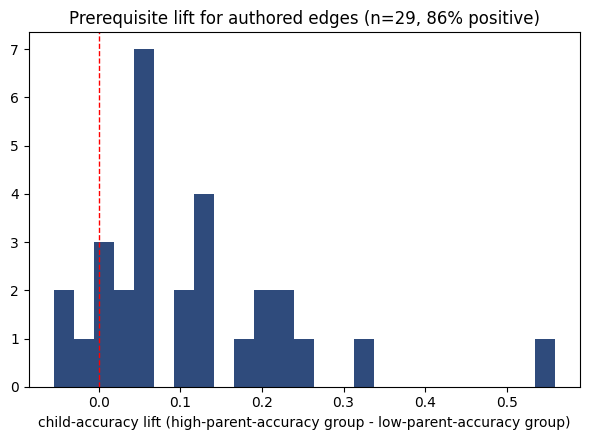

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(lift_df["lift"], bins=25, color="#2F4B7C")
ax.axvline(0, color="red", ls="--", lw=1)
ax.set_xlabel("child-accuracy lift (high-parent-accuracy group - low-parent-accuracy group)")
ax.set_title(f"Prerequisite lift for authored edges (n={len(lift_df)}, {(lift_df['lift']>0).mean():.0%} positive)")
plt.tight_layout()
fig.savefig(FIG / "05_prerequisite_lift.png", dpi=120)
plt.show()


**Reading this result.** If the authored tree encodes real prerequisites, most edges
should show positive lift (students who do well on the parent do better on the child than
students who do poorly on the parent, beyond what general ability alone would predict).
A lift concentrated well above zero supports using the tree to suppress child priors
(RQ1.3); a lift centered near zero would mean the authored *depth* ordering doesn't
track actual prerequisite gating and the Diagnostic module should not lean on it as-is.

## 3. Data-driven direction discovery vs. the authored tree

In [6]:
error_by_kc = kc_meta.set_index("kc_id")["error_rate"]
co_pairs = pd.DataFrame(
    [{"kc_a": a, "kc_b": b} for a, b in combinations(top_kcs, 2)]
)
discovered = prerequisites.discover_prerequisite_direction(error_by_kc, co_pairs)

authored_edge_set = set(zip(edges["parent"].map(lambda n: name_to_id.get(n)), edges["child"].map(lambda n: name_to_id.get(n))))
authored_edge_set = {e for e in authored_edge_set if None not in e}
agreement = prerequisites.agreement_with_authored_tree(discovered, authored_edge_set)
print(f"Data-driven (lower-error-first) direction agrees with the authored tree for "
      f"{agreement:.1%} of {len(discovered)} candidate KC pairs among the top-{len(top_kcs)} KCs.")


Data-driven (lower-error-first) direction agrees with the authored tree for 0.0% of 179700 candidate KC pairs among the top-600 KCs.


In [7]:
discovered.to_csv(OUT / "prerequisite_edges.csv", index=False)
lift_df.to_csv(OUT / "prerequisite_lift.csv", index=False)
print("saved outcomes/prerequisite_edges.csv, outcomes/prerequisite_lift.csv")


saved outcomes/prerequisite_edges.csv, outcomes/prerequisite_lift.csv


In [8]:
with tracking.start_run("05_kc_prerequisites", "prerequisites", params={
    "n_authored_edges_tested": len(lift_df), "n_top_kcs": len(top_kcs),
}):
    mlflow.log_metric("pct_positive_lift", float((lift_df["lift"] > 0).mean()))
    mlflow.log_metric("mean_lift", float(lift_df["lift"].mean()))
    mlflow.log_metric("discovered_tree_agreement", float(agreement))
    mlflow.log_artifact(str(OUT / "prerequisite_edges.csv"))
    mlflow.log_artifact(str(FIG / "05_prerequisite_lift.png"))
print("logged to mlflow")


2026/07/12 02:13:02 INFO mlflow.tracking.fluent: Experiment with name 'noxed-prerequisites' does not exist. Creating a new experiment.


2026/07/12 02:13:02 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



logged to mlflow


## Findings → consumed by

- `outcomes/prerequisite_lift.csv` — per-edge evidence for whether the authored tree
  gates real performance → **Diagnostic** module's RQ1.3 prior-suppression rule; edges
  with low/negative lift should NOT suppress child priors as strongly as high-lift edges.
- `outcomes/prerequisite_edges.csv` — data-driven direction proposals, cross-checkable
  against future authored-tree revisions.